# 🎯 뉴스 분류 파이프라인 실습 (Instructor)

- **데이터 소개**
  - 이 실습에서는 **KLUE의 YNAT 뉴스 주제 분류 데이터**를 사용합니다.
  - 이 데이터는 **연합뉴스 뉴스 제목**을 바탕으로 만든 한국어 분류 데이터이며, 기사 본문이 아니라 **제목만 보고** 주제를 예측합니다.
  - 분류 범주는 **정치, 경제, 사회, 생활문화, 세계, IT/과학, 스포츠**의 7개입니다.
  - 데이터와 벤치마크 정보는 `https://klue-benchmark.com/`, 데이터셋은 `https://huggingface.co/datasets/klue/klue`에서 확인할 수 있습니다.
- **실습 목표**
  - 이번 실습에서는 이 데이터를 **TF-IDF + RF/LogReg**으로 분류하고, 성적표와 혼동행렬을 해석합니다.
  - 강의 포인트는 복잡한 딥러닝 구현보다, 텍스트 벡터화와 분류기 결과를 비교 해석하는 데 있습니다.

> **🖥️ 환경 설정**: `uv run jupyter lab`으로 실행하세요.
> 추가 패키지 필요 시: `uv add koreanize-matplotlib scikit-learn seaborn`

> **⌨️ 단축키 안내**
> | 단축키 | 동작 |
> |--------|------|
> | `Shift + Enter` | 셀 실행 후 다음 셀 이동 |
> | `Esc → A` | 위에 셀 삽입 |
> | `Esc → B` | 아래에 셀 삽입 |
> | `Esc → DD` | 셀 삭제 |

In [1]:
# !uv pip install koreanize-matplotlib scikit-learn seaborn -q

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

%config InlineBackend.figure_format = 'retina'

## 📂 데이터 로드

KLUE 뉴스 데이터를 로드하고 구조를 확인합니다. 이론 수업에서 배운 파이프라인의 첫 단계입니다.

[→ §100 강의노트](../notes/UD-06-100__text-classification-intro.md)

In [4]:
# 📌 §100 데이터 로드
train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/unstructured-data/data/klue/train_data.csv")
test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/unstructured-data/data/klue/test_data.csv")
print(f"학습: {train.shape}, 시험: {test.shape}")
# 예상 출력: 학습: (45654, 3), 시험: (9131, 2)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/unstructured-data/data/klue/train_data.csv'

In [6]:
# 📌 §100 데이터 확인
train.head()
# 예상 출력: index, title, topic_idx 열이 보이는 DataFrame

,index,title,topic_idx
0,0,인천→핀란드 항공기 결항…휴가철 여행객 분통,4
1,1,실리콘밸리 넘어서겠다…구글 15조원 들여 美전역 거점화,4
2,2,이란 외무 긴장완화 해결책은 미국이 경제전쟁 멈추는 것,4
3,3,NYT 클린턴 측근韓기업 특수관계 조명…공과 사 맞물려종합,4
4,4,시진핑 트럼프에 중미 무역협상 조속 타결 희망,4


In [ ]:
# 📌 §100 카테고리 확인
topic = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/unstructured-data/data/klue/topic_dict.csv")
print(topic)
print(f"\n카테고리별 건수:")
print(train["topic_idx"].value_counts().sort_index())
# 예상 출력: 7개 카테고리 (0:IT과학 ~ 6:정치), 4824~7629건

  topic  topic_idx
0  IT과학          0
1    경제          1
2    사회          2
3  생활문화          3
4    세계          4
5   스포츠          5
6    정치          6

카테고리별 건수:
topic_idx
0    4824
1    6222
2    7362
3    5933
4    7629
5    6933
6    6751
Name: count, dtype: int64


## 🧹 전처리

숫자를 제거하고 영문을 소문자로 바꿉니다. 형태소 분석 없이 TF-IDF ngram만으로도 충분한 성능이 나옵니다.

[→ §400 강의노트](../notes/UD-06-400__demo-classification-report.md)

In [8]:
# 📌 §400 전처리
train["title"] = train["title"].str.replace("[0-9]", "", regex=True).str.lower()
test["title"] = test["title"].str.replace("[0-9]", "", regex=True).str.lower()
print(train["title"].head(3))
# 예상 출력: 숫자가 제거된 뉴스 제목 3건

0          인천→핀란드 항공기 결항…휴가철 여행객 분통
1      실리콘밸리 넘어서겠다…구글 조원 들여 美전역 거점화
2    이란 외무 긴장완화 해결책은 미국이 경제전쟁 멈추는 것
Name: title, dtype: str


## 🔢 TF-IDF 벡터화

W05에서 배운 TF-IDF를 적용합니다. 학습 데이터로 단어 사전을 만들고(fit), 학습/시험 데이터를 모두 벡터로 변환합니다(transform).

[→ §400 강의노트](../notes/UD-06-400__demo-classification-report.md)

[🔗 TfidfVectorizer 공식 문서](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)

In [9]:
# 📌 §400 TF-IDF 생성
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.95)
tfidf.fit(train["title"])
print(f"단어 사전 크기: {len(tfidf.get_feature_names_out())}")
# 예상 출력: 단어 사전 크기: 22385

단어 사전 크기: 22385


In [10]:
# 📌 §400 벡터 변환
X_train = tfidf.transform(train["title"])
y_train = train["topic_idx"]
X_test = tfidf.transform(test["title"])
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
# 예상 출력: X_train: (45654, 22385), X_test: (9131, 22385)

X_train: (45654, 22385), X_test: (9131, 22385)


## 🌲 RandomForest 학습

100개 트리가 투표하는 랜덤 포레스트로 뉴스를 분류합니다. 교차검증으로 정확도를 확인합니다.

[→ §300 강의노트](../notes/UD-06-300__rf-vs-logreg.md)

[🔗 RandomForestClassifier 공식 문서](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

> ⏱️ **실행 시간 안내**: 아래 셀은 3-fold 교차검증으로 RF 100개 트리를 학습합니다. **1~3분** 소요됩니다. 실행 후 기다려주세요.

### 교차검증(Cross-Validation)이란?

**핵심 아이디어**: 데이터를 여러 조각으로 나눠서, 번갈아가며 "이 조각은 시험, 나머지는 학습"을 반복합니다.

아래 애니메이션은 `cross_val_predict(rf, X_train, y_train, cv=3)`가 내부적으로 하는 일을 보여줍니다.

![cross_val_predict 3-fold 애니메이션](images/cross_val_predict.gif)

| 단계 | 설명 |
|------|------|
| **Fold 1 예측** | Fold 2 + Fold 3으로 학습 → Fold 1 예측 |
| **Fold 2 예측** | Fold 1 + Fold 3으로 학습 → Fold 2 예측 |
| **Fold 3 예측** | Fold 1 + Fold 2로 학습 → Fold 3 예측 |
| **결과 합치기** | 세 조각의 예측을 원래 순서로 이어 붙임 |

> **왜 교차검증을 쓰나요?**  
> 같은 데이터로 학습하고 평가하면 "내가 본 문제만 잘 푸는" 과적합 평가가 됩니다.  
> 교차검증은 모든 샘플을 한 번씩 "처음 보는 문제"로 예측하게 해서 더 공정한 성능 측정이 가능합니다.

> **`cross_val_predict` 반환값**  
> 예측 결과 3세트가 아니라, **전체 샘플에 대한 예측 1세트**가 반환됩니다.  
> → `y_pred_rf`의 길이 == `y_train`의 길이

### cross_val_predict가 어떻게 예측을 모으는가

```text
데이터를 3등분
  Fold 1 | Fold 2 | Fold 3

1차
  학습: Fold 2 + Fold 3
  예측: Fold 1

2차
  학습: Fold 1 + Fold 3
  예측: Fold 2

3차
  학습: Fold 1 + Fold 2
  예측: Fold 3

세 번의 부분 예측을 원래 순서로 합치면
  y_pred_rf = [Fold 1 예측, Fold 2 예측, Fold 3 예측을 원래 자리로 합친 결과]
```

- 중요: 예측 결과가 3세트 반환되는 것이 아니라, 모든 샘플에 대한 최종 예측 1세트가 반환됩니다.
- 즉, `y_pred_rf`의 길이는 `y_train`과 같습니다.

In [11]:
# 📌 §300 RF 학습
rf = RandomForestClassifier(n_estimators=100, random_state=42)
y_pred_rf = cross_val_predict(rf, X_train, y_train, cv=3)
# 예상 출력: (시간이 걸립니다 — 1~3분 소요)

KeyboardInterrupt: 

In [9]:
# 📌 §300 RF 정확도
rf_accuracy = (y_pred_rf == y_train).mean()
print(f"RF 교차검증 정확도: {rf_accuracy:.4f}")
# 예상 출력: RF 교차검증 정확도: 0.7395

RF 교차검증 정확도: 0.7395


## 📈 LogisticRegression 학습

S-curve로 확률을 계산하는 로지스틱 회귀로 같은 데이터를 분류합니다. RF보다 빠르고, 텍스트 분류에서 강력한 baseline입니다.

[→ §300 강의노트](../notes/UD-06-300__rf-vs-logreg.md)

[🔗 LogisticRegression 공식 문서](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

In [10]:
# 📌 §300 LogReg 학습
lr = LogisticRegression(max_iter=1000, random_state=42)
y_pred_lr = cross_val_predict(lr, X_train, y_train, cv=3)
# 예상 출력: (RF보다 훨씬 빠릅니다 — 수 초 소요)

In [11]:
# 📌 §300 LogReg 정확도
lr_accuracy = (y_pred_lr == y_train).mean()
print(f"LogReg 교차검증 정확도: {lr_accuracy:.4f}")
# 예상 출력: LogReg 교차검증 정확도: 0.7871

LogReg 교차검증 정확도: 0.7871


## 📋 성적표 (classification_report)

전체 정확도만으로는 부족합니다. 카테고리별 Precision, Recall, F1-score를 확인해서 어디를 잘 맞추고 어디를 못 맞추는지 살펴봅니다.

[→ §400 강의노트](../notes/UD-06-400__demo-classification-report.md)

[🔗 classification_report 공식 문서](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

In [12]:
# 📌 §400 LogReg 성적표
labels = topic["topic"].values
print(classification_report(y_train, y_pred_lr, target_names=labels))
# 예상 출력: 스포츠 F1≈0.92 (최고), 사회 F1≈0.65 (최저)

              precision    recall  f1-score   support

        IT과학       0.76      0.75      0.75      4824
          경제       0.79      0.72      0.75      6222
          사회       0.60      0.71      0.65      7362
        생활문화       0.82      0.79      0.80      5933
          세계       0.81      0.81      0.81      7629
         스포츠       0.94      0.91      0.92      6933
          정치       0.84      0.82      0.83      6751

    accuracy                           0.79     45654
   macro avg       0.79      0.78      0.79     45654
weighted avg       0.79      0.79      0.79     45654



In [13]:
# 📌 §400 RF 성적표
print(classification_report(y_train, y_pred_rf, target_names=labels))
# 예상 출력: RF도 스포츠 최고, 사회 
# 최저 — LogReg보다 전반적으로 살짝 낮음

              precision    recall  f1-score   support

        IT과학       0.69      0.75      0.72      4824
          경제       0.75      0.66      0.71      6222
          사회       0.56      0.63      0.59      7362
        생활문화       0.67      0.77      0.72      5933
          세계       0.82      0.72      0.77      7629
         스포츠       0.92      0.87      0.89      6933
          정치       0.81      0.78      0.79      6751

    accuracy                           0.74     45654
   macro avg       0.75      0.74      0.74     45654
weighted avg       0.75      0.74      0.74     45654



## 🔥 혼동행렬

어떤 카테고리끼리 혼동하는지 7×7 행렬로 확인합니다. 대각선이 맞춘 건수, 나머지가 틀린 건수입니다.

[→ §400 강의노트](../notes/UD-06-400__demo-classification-report.md)

In [14]:
# 📌 §400 혼동행렬 계산
cm = confusion_matrix(y_train, y_pred_lr)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df
# 예상 출력: 7×7 혼동행렬 DataFrame

,IT과학,경제,사회,생활문화,세계,스포츠,정치
IT과학,3595,294,564,160,118,39,54
경제,516,4463,789,103,215,48,88
사회,318,456,5205,423,418,86,456
생활문화,114,95,734,4680,178,59,73
세계,112,233,500,169,6164,119,332
스포츠,32,46,226,108,138,6300,83
정치,27,54,618,68,416,41,5527


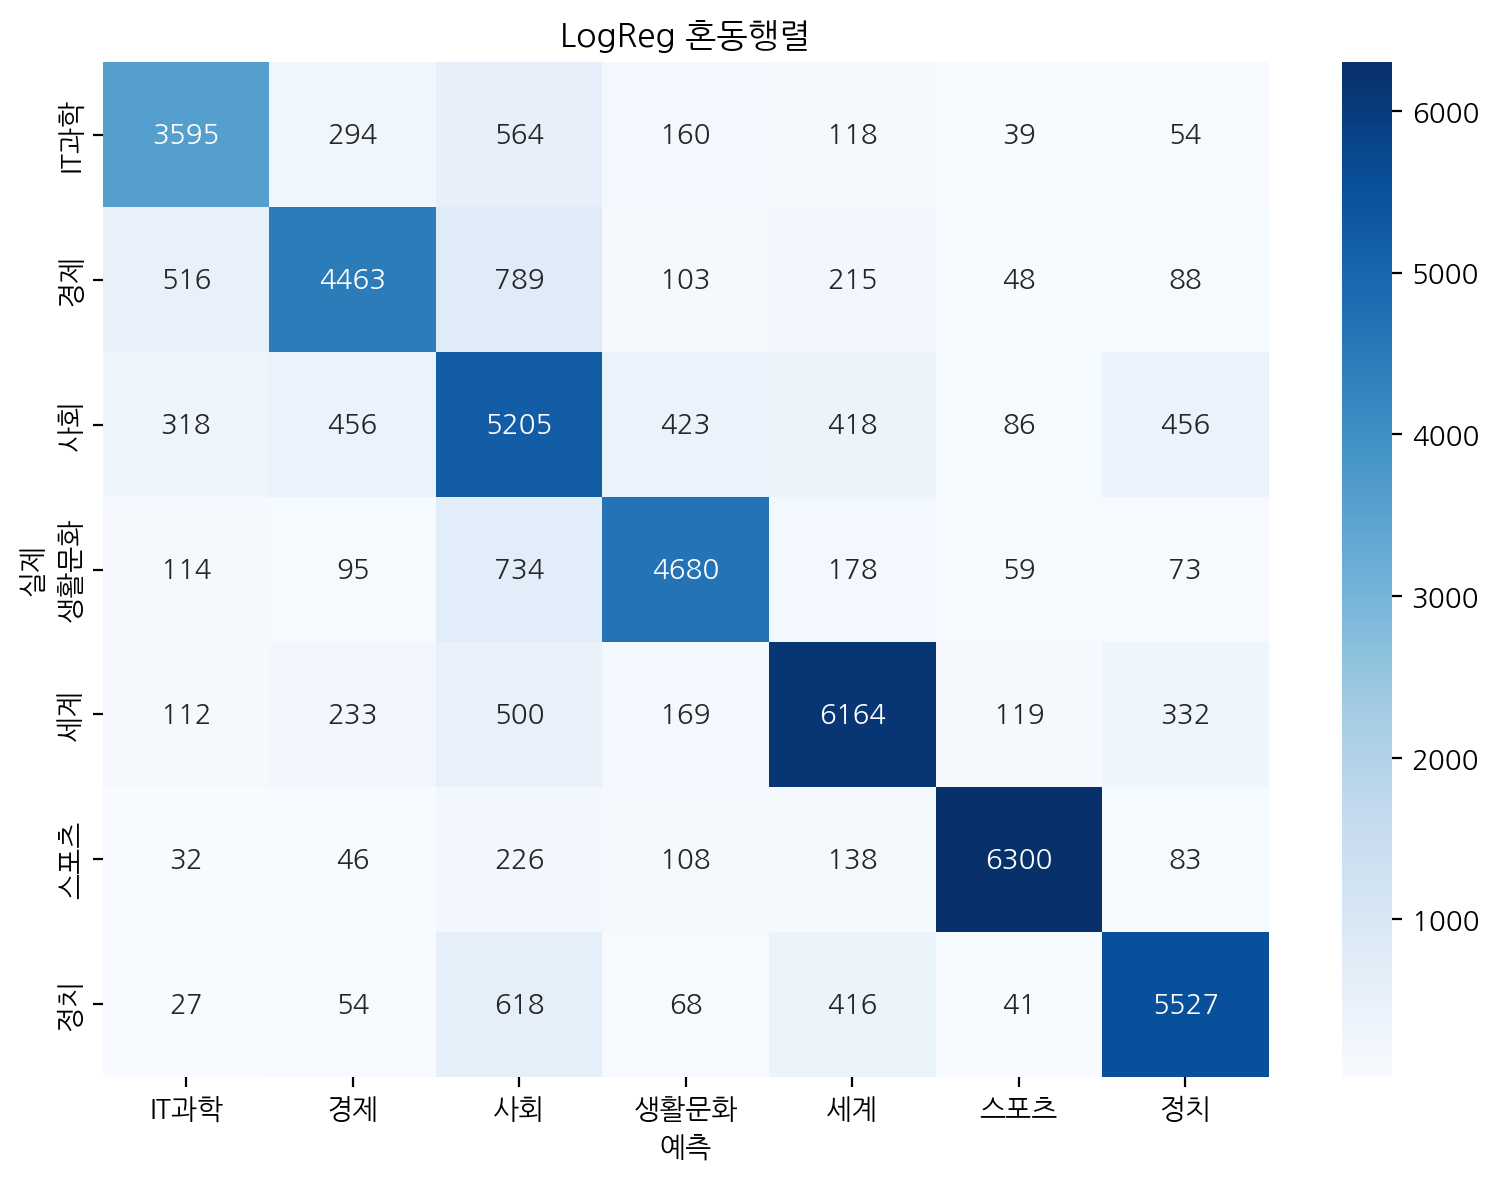

In [15]:
# 📌 §400 혼동행렬 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.xlabel("예측")
plt.ylabel("실제")
plt.title("LogReg 혼동행렬")
plt.tight_layout()
plt.show()
# 예상 출력: 대각선이 진하고, 사회-정치 영역이 밝은 heatmap

In [16]:
# 📌 §400 혼동 패턴
print(f"사회→정치 혼동: {cm_df.loc['사회', '정치']}건")
print(f"정치→사회 혼동: {cm_df.loc['정치', '사회']}건")
print(f"경제→사회 혼동: {cm_df.loc['경제', '사회']}건")
# 예상 출력: 사회→정치 456건, 정치→사회 618건, 경제→사회 789건

사회→정치 혼동: 456건
정치→사회 혼동: 618건
경제→사회 혼동: 789건


## 🔍 predict_proba — 모델의 확신도

predict()는 카테고리 번호만 알려주지만, predict_proba()는 각 카테고리에 대한 확률을 보여줍니다. 모델이 얼마나 확신하는지 들여다봅니다.

[→ §300 강의노트](../notes/UD-06-300__rf-vs-logreg.md)

In [17]:
# 📌 §300 LogReg 확률 예측
lr.fit(X_train, y_train)
lr_proba = lr.predict_proba(X_test[:3])
print(pd.DataFrame(lr_proba, columns=labels).round(2))
# 예상 출력: 3행 × 7열 — 각 행의 합이 1.0, 가장 높은 확률이 예측 카테고리

   IT과학    경제    사회  생활문화    세계   스포츠    정치
0  0.10  0.05  0.46  0.28  0.03  0.03  0.04
1  0.05  0.06  0.09  0.60  0.08  0.06  0.07
2  0.06  0.16  0.43  0.06  0.12  0.07  0.10


In [18]:
# 📌 §300 RF 확률 예측
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test[:3])
print(pd.DataFrame(rf_proba, columns=labels).round(2))
# 예상 출력: RF는 투표 비율이라 확률이 더 뭉뚝한 형태 (0.7~0.9 vs 0.01~0.05)

   IT과학    경제    사회  생활문화    세계   스포츠    정치
0  0.03  0.07  0.69  0.07  0.04  0.02  0.08
1  0.02  0.04  0.14  0.72  0.02  0.01  0.05
2  0.09  0.24  0.53  0.03  0.06  0.01  0.04


## ⚖️ 모델 비교 정리

같은 TF-IDF 벡터에서 분류기만 바꿨을 때, 어떤 차이가 나는지 정리합니다.

[→ §400 강의노트](../notes/UD-06-400__demo-classification-report.md)

In [19]:
# 📌 §400 모델 비교
print(f"{'모델':<20} {'정확도':>8}")
print("-" * 30)
print(f"{'RandomForest':<20} {rf_accuracy:>8.4f}")
print(f"{'LogisticRegression':<20} {lr_accuracy:>8.4f}")
print(f"\n→ LogReg이 더 높은 정확도 + 더 빠른 학습")
# 예상 출력: RF 0.7395, LogReg 0.7871

모델                        정확도
------------------------------
RandomForest           0.7395
LogisticRegression     0.7871

→ LogReg이 더 높은 정확도 + 더 빠른 학습


## 📊 모델이 어떤 단어를 증거로 썼는가

RF가 뉴스를 분류할 때 어떤 단어에 주목했는지 `feature_importances_`로 확인합니다.

[→ §500 강의노트](../notes/UD-06-500__eda-feature-importance.md)

[🔗 RandomForestClassifier.feature_importances_ 공식 문서](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier.feature_importances_)

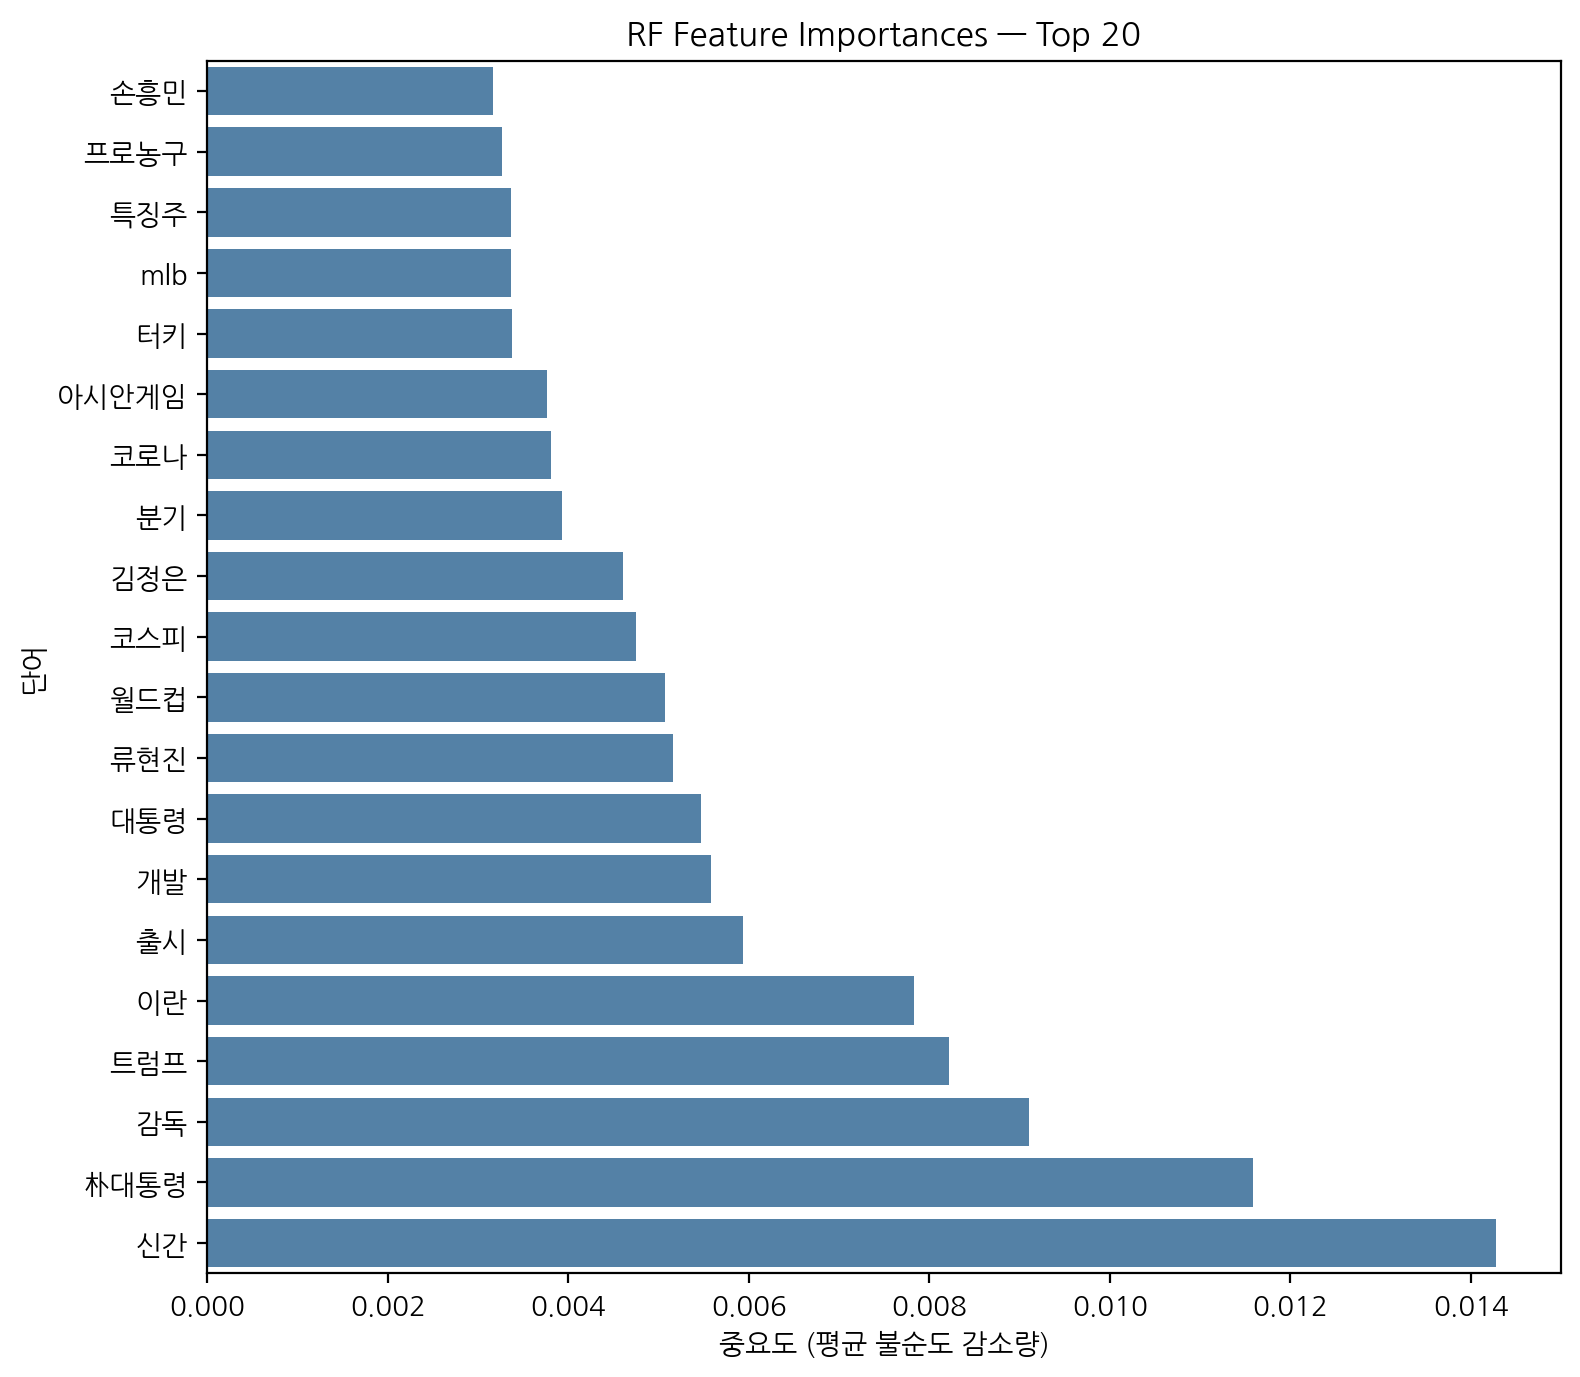

In [20]:
# 📌 §500 RF feature_importances_ Top 20
feat_names = tfidf.get_feature_names_out()
importances = rf.feature_importances_

fi_df = pd.DataFrame({"단어": feat_names, "중요도": importances})
fi_df = fi_df.sort_values("중요도", ascending=False).head(20)
fi_df = fi_df.sort_values("중요도")  # barh: 오름차순 → 위에 높은 값

plt.figure(figsize=(8, 7))
sns.barplot(data=fi_df, x="중요도", y="단어", color="steelblue")
plt.title("RF Feature Importances — Top 20")
plt.xlabel("중요도 (평균 불순도 감소량)")
plt.tight_layout()
plt.show()
# 예상 출력: 수평 막대그래프 — 스포츠 관련 단어가 상위 독점

In [21]:
# 📌 §500 상위 단어 출력 및 해석
top10 = fi_df.sort_values("중요도", ascending=False).head(10)
print("Top 10 중요 단어:")
print(top10.to_string(index=False))
print()
print("→ 스포츠 단어('골', '감독', '경기')가 상위 독점: 스포츠 F1=0.92 이유")
print("→ 사회 관련 단어 거의 없음: 사회 어휘는 다른 카테고리와 겹치기 때문")
# 예상 출력: Top 10 단어 테이블 + 해석 메시지

Top 10 중요 단어:
  단어      중요도
  신간 0.014280
朴대통령 0.011585
  감독 0.009107
 트럼프 0.008214
  이란 0.007831
  출시 0.005941
  개발 0.005583
 대통령 0.005468
 류현진 0.005160
 월드컵 0.005074

→ 스포츠 단어('골', '감독', '경기')가 상위 독점: 스포츠 F1=0.92 이유
→ 사회 관련 단어 거의 없음: 사회 어휘는 다른 카테고리와 겹치기 때문


## 🔤 도전: 형태소 분석으로 성능 올리기

현재 전처리는 숫자 제거 + 소문자 변환뿐입니다. Pecab 형태소 분석기로 조사와 구두점을 제거하면 성능이 달라질까요?

> ⏱️ **실행 시간 안내**: Pecab 전처리는 45,654건 기준 **3~5분** 소요됩니다.

[→ §500 강의노트](../notes/UD-06-500__eda-feature-importance.md)

In [22]:
# 📌 §600 Pecab 설치 및 임포트
# !uv pip install pecab -q
from pecab import PeCab
pecab_analyzer = PeCab()
print("Pecab 초기화 완료")
# 예상 출력: Pecab 초기화 완료

Pecab 초기화 완료


In [23]:
# 📌 §600 Pecab 전처리 함수
def pecab_clean(text):
    """조사(J*)와 문장부호(SF)를 제거하고 나머지 형태소를 space-join"""
    tokens = pecab_analyzer.pos(text, drop_space=False)
    filtered = [word for word, pos in tokens
                if not (pos.startswith("J") or pos == "SF")]
    return " ".join(filtered)

# 동작 확인
sample = "삼성전자가 신제품을 출시했다"
print(f"원문: {sample}")
print(f"Pecab: {pecab_clean(sample)}")
# 예상 출력: 원문: 삼성전자가 신제품을 출시했다 → Pecab: 조사 제거된 형태소

원문: 삼성전자가 신제품을 출시했다
Pecab: 삼성전자   신 제품   출시 했 다


In [24]:
# 📌 §600 Pecab 전처리 적용
# ⏱️ 45,654건 형태소 분석 — 3~5분 소요
train2 = pd.read_csv("data/klue/train_data.csv")  # 원본 재로드
train2["title_clean"] = train2["title"].apply(pecab_clean)
print(f"전처리 완료: {len(train2)}건")
print(train2[["title", "title_clean"]].head(3))
# 예상 출력: 전처리 완료: 45654건 + 원문/Pecab 비교 3건

/Users/mark/Projects/Education/UD_26/.venv/lib/python3.12/site-packages/pecab/_tokenizer.py:265: RuntimeWarning: overflow encountered in scalar add
  from_pos_data.costs[idx]
/Users/mark/Projects/Education/UD_26/.venv/lib/python3.12/site-packages/pecab/_tokenizer.py:274: RuntimeWarning: overflow encountered in scalar add
  least_cost += word_cost


전처리 완료: 45654건
                            title  \
0        인천→핀란드 항공기 결항…휴가철 여행객 분통   
1  실리콘밸리 넘어서겠다…구글 15조원 들여 美전역 거점화   
2  이란 외무 긴장완화 해결책은 미국이 경제전쟁 멈추는 것   

                                         title_clean  
0               인천 → 핀란드   항공기   결항 … 휴가철   여행객   분통  
1  실리콘밸리   넘어서 겠 다 … 구글   1 5 조 원   들여   美 전역   거점 화  
2     이 란   외무   긴장 완화   해결책   미국   경제 전쟁   멈추 는   것  


In [25]:
# 📌 §600 Pecab TF-IDF + LogReg
tfidf_pc = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.95)
X_train_pc = tfidf_pc.fit_transform(train2["title_clean"])
y_train2 = train2["topic_idx"]

lr_pc = LogisticRegression(max_iter=1000, random_state=42)
y_pred_pc = cross_val_predict(lr_pc, X_train_pc, y_train2, cv=3)
pc_accuracy = (y_pred_pc == y_train2).mean()

print(f"단어 사전 크기: {len(tfidf_pc.get_feature_names_out())}")
print(f"Pecab LogReg 정확도: {pc_accuracy:.4f}")
# 예상 출력: Pecab LogReg 정확도: ~0.82 (단순 전처리 0.7871 대비)

단어 사전 크기: 23324
Pecab LogReg 정확도: 0.8150


In [27]:
# 📌 §600 전처리 방법 비교
print(f"{'전처리 방법':<25} {'정확도':>8}")
print("-" * 35)
print(f"{'단순 (숫자제거+소문자)':<25} {lr_accuracy:>8.4f}")
print(f"{'Pecab (형태소 분석)':<25} {pc_accuracy:>8.4f}")
delta = pc_accuracy - lr_accuracy
print(f"\n→ 차이: {delta:+.4f} ({'향상' if delta > 0 else '하락'})")
print("→ 전처리만 바꿔도 성능이 달라진다!")
# 예상 출력: 두 방법 정확도 비교 + 차이

전처리 방법                         정확도
-----------------------------------
단순 (숫자제거+소문자)               0.7871
Pecab (형태소 분석)              0.8150

→ 차이: +0.0279 (향상)
→ 전처리만 바꿔도 성능이 달라진다!
